In [1]:
# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import models, layers

import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
def create_diagonal_stripes(img_size=28, stripe_width=4):
    img = np.zeros((img_size, img_size), dtype=np.float32)
    for i in range(img_size):
        for j in range(img_size):
            if ((i - j) // stripe_width) % 2 == 0:
                img[i, j] = 1.0
    return img


def create_checkerboard(img_size=28, block_size=4):
    img = np.zeros((img_size, img_size), dtype=np.float32)
    for i in range(img_size):
        for j in range(img_size):
            if ((i // block_size) + (j // block_size)) % 2 == 0:
                img[i, j] = 1.0
    return img


num_samples_per_class = 500

images = []
labels = []

# Diagonal stripes class (label = 0)
for _ in range(num_samples_per_class):
    images.append(create_diagonal_stripes())
    labels.append(0)

# Checkerboard class (label = 1)
for _ in range(num_samples_per_class):
    images.append(create_checkerboard())
    labels.append(1)

images = np.array(images)
labels = np.array(labels)

# Prepare data for CNN
X = images.reshape(-1, 28, 28, 1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Step 3: Preprocess Data
# Reshape input to include channel dimension
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32")
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32")
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

In [4]:
# Step 4: Build CNN Model
model = models.Sequential([
    # layers.Conv2D(16, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.Input(shape=(28, 28, 1)), # Getting rid of the warning
    layers.Conv2D(16, (3, 3), activation="relu"),  # ← remove input_shape here
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(2, activation="softmax") # 2 classes Diagonal stripes class and Checkerboard class
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,194 (219.51 KB)

 Trainable params: 56,194 (219.51 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Step 5: Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [6]:
# Step 6: Train Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8062 - loss: 0.4015 - val_accuracy: 1.0000 - val_loss: 0.0920
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0294 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 5.7731e-04
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 4.0083e-04 - val_accuracy: 1.0000 - val_loss: 2.6336e-04
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 2.2553e-04 - val_accuracy: 1.0000 - val_loss: 1.8631e-04
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 1.7198e-04 - val_accuracy: 1.0000 - val_loss: 1.5410e-04
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 1.4635e-04 - val_accuracy: 1.0000 - val_loss: 1.3510e-04
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - los

In [7]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

7/7 - 0s - 17ms/step - accuracy: 1.0000 - loss: 1.0005e-04

Test accuracy: 1.0000


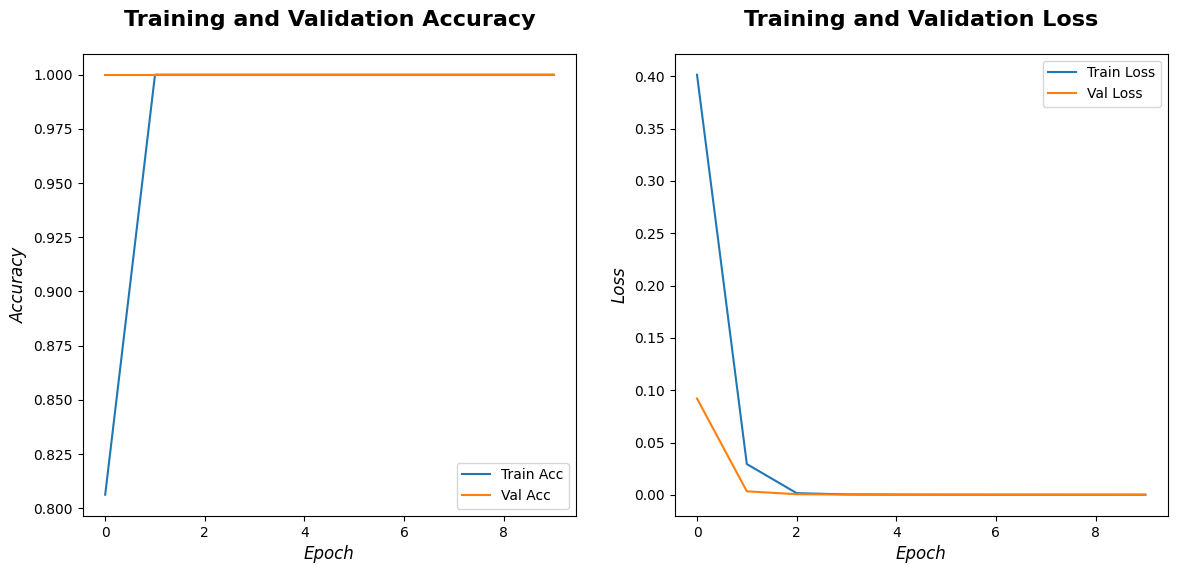

In [8]:
# Step 8: Plot Training & Validation Metrics
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Training and Validation Accuracy", fontweight="bold", fontsize=16, pad=20)
plt.xlabel("Epoch", fontsize=12, fontstyle="italic")
plt.ylabel("Accuracy", fontsize=12, fontstyle="italic")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss", fontweight="bold", fontsize=16, pad=20)
plt.xlabel("Epoch", fontsize=12, fontstyle="italic")
plt.ylabel("Loss", fontsize=12, fontstyle="italic")
plt.legend()

plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


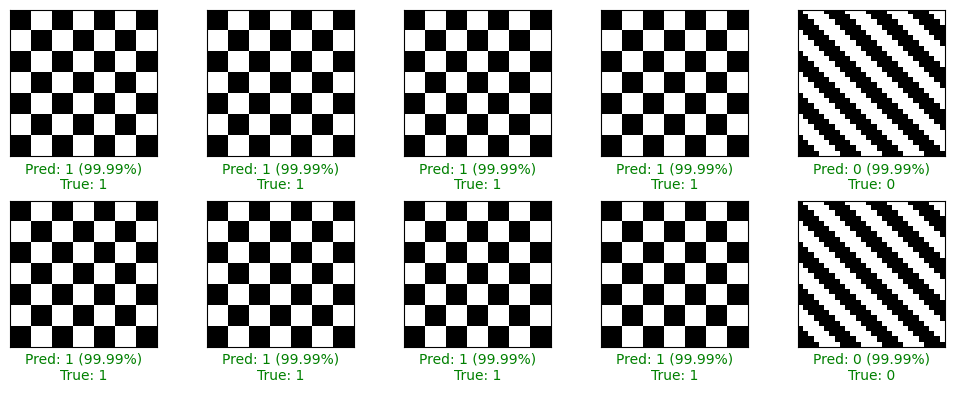

In [9]:
predictions = model.predict(X_test)

def plot_image(i, predictions_array, true_labels, images):
    predictions_array = predictions_array[i]
    true_label = np.argmax(true_labels[i]) if len(true_labels.shape) > 1 else true_labels[i]
    img = images[i].reshape(28, 28)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(
        f"Pred: {predicted_label} ({100*np.max(predictions_array):.2f}%)\nTrue: {true_label}",
        color=color
    )

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plot_image(i, predictions, y_test, X_test)

plt.tight_layout()
plt.show()